# UPI/Mobile Money Fraud Detection — PaySim Analysis

SQL-driven exploration, leakage-aware feature engineering, explainable ML, and a
precision/recall tradeoff framed as a business decision — simulating the kind of
risk-analyst work done at a UPI-scale payments company.

**Dataset:** [PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1) (Kaggle) — 6.3M+
real transactions, standard academic mobile-money fraud benchmark.

In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn shap kaggle -q

In [7]:
import os
from google.colab import userdata

# Store your token in Colab's Secrets manager (key icon, left sidebar) as
# KAGGLE_API_TOKEN — never hardcode a token directly in a notebook cell.
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

SecretNotFoundError: Secret KAGGLE_API_TOKEN does not exist.

In [5]:
!kaggle datasets download -d ealaxi/paysim1
!unzip -q paysim1.zip

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:01<00:00, 128MB/s]



In [6]:
import pandas as pd

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
import sqlite3

conn = sqlite3.connect('paysim.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)

conn.execute('CREATE INDEX idx_type ON transactions(type)')
conn.execute('CREATE INDEX idx_fraud ON transactions(isFraud)')
conn.execute('CREATE INDEX idx_orig ON transactions(nameOrig)')
conn.commit()

print("Loaded", len(df), "rows into SQLite")

Loaded 6362620 rows into SQLite


# 1. Exploratory SQL

In [9]:
pd.read_sql_query("""
    SELECT type, COUNT(*) as txn_count,
           ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM transactions),2) as pct,
           ROUND(SUM(amount),2) as total_value
    FROM transactions
    GROUP BY type
    ORDER BY txn_count DESC
""", conn)

,type,txn_count,pct,total_value
0,CASH_OUT,2237500,35.17,3.944130e+11
1,PAYMENT,2151495,33.81,2.809337e+10
2,CASH_IN,1399284,21.99,2.363674e+11
3,TRANSFER,532909,8.38,4.852920e+11
4,DEBIT,41432,0.65,2.271992e+08


In [10]:
pd.read_sql_query("""
    SELECT type,
           COUNT(*) as total_txns,
           SUM(isFraud) as fraud_txns,
           ROUND(100.0*SUM(isFraud)/COUNT(*), 4) as fraud_rate_pct
    FROM transactions
    GROUP BY type
    ORDER BY fraud_rate_pct DESC
""", conn)

,type,total_txns,fraud_txns,fraud_rate_pct
0,TRANSFER,532909,4097,0.7688
1,CASH_OUT,2237500,4116,0.1840
2,CASH_IN,1399284,0,0.0000
3,DEBIT,41432,0,0.0000
4,PAYMENT,2151495,0,0.0000


In [11]:
pd.read_sql_query("""
    SELECT isFraud, COUNT(*) as n,
           ROUND(AVG(amount),2) as avg_amount,
           ROUND(MIN(amount),2) as min_amount,
           ROUND(MAX(amount),2) as max_amount
    FROM transactions
    GROUP BY isFraud
""", conn)

,isFraud,n,avg_amount,min_amount,max_amount
0,0,6354407,178197.04,0.01,92445516.64
1,1,8213,1467967.30,0.00,10000000.00


In [12]:
pd.read_sql_query("""
    SELECT isFraud, isFlaggedFraud, COUNT(*) as n
    FROM transactions
    GROUP BY isFraud, isFlaggedFraud
""", conn)

,isFraud,isFlaggedFraud,n
0,0,0,6354407
1,1,0,8197
2,1,1,16


In [13]:
pd.read_sql_query("""
    WITH sender_activity AS (
        SELECT nameOrig,
               COUNT(*) as txn_count,
               SUM(amount) as total_sent,
               SUM(isFraud) as fraud_count
        FROM transactions
        GROUP BY nameOrig
    )
    SELECT *,
           RANK() OVER (ORDER BY total_sent DESC) as sender_rank
    FROM sender_activity
    WHERE fraud_count > 0
    ORDER BY total_sent DESC
    LIMIT 20
""", conn)

,nameOrig,txn_count,total_sent,fraud_count,sender_rank
0,C1004068843,1,10000000.0,1,1
1,C1014298205,1,10000000.0,1,1
2,C1016892734,1,10000000.0,1,1
3,C1028530067,1,10000000.0,1,1
4,C1036572575,1,10000000.0,1,1
5,C1041060645,1,10000000.0,1,1
6,C1045409609,1,10000000.0,1,1
7,C1046281837,1,10000000.0,1,1
8,C1049094143,1,10000000.0,1,1
9,C1057439889,1,10000000.0,1,1


## 2. Hypothesis testing — transaction frequency per sender

Tested whether fraud accounts show single-transaction behavior. **Result: rejected**
— both fraud and legitimate senders average ~1.0 transactions/account, a structural
property of PaySim's account IDs rather than a fraud signal.

In [14]:
pd.read_sql_query("""
    SELECT
        isFraud,
        AVG(txn_count) as avg_txns_per_sender,
        AVG(CASE WHEN txn_count = 1 THEN 1.0 ELSE 0.0 END) as pct_single_txn_senders
    FROM (
        SELECT nameOrig, isFraud, COUNT(*) as txn_count
        FROM transactions
        GROUP BY nameOrig, isFraud
    )
    GROUP BY isFraud
""", conn)

,isFraud,avg_txns_per_sender,pct_single_txn_senders
0,0,1.001463,0.998539
1,1,1.000000,1.000000


## 3. Feature discovery — the balance-consistency signal

Exploring PaySim's balance columns for a real, non-trivial fraud signal.

In [15]:
pd.read_sql_query("""
    SELECT
        isFraud,
        SUM(CASE WHEN oldbalanceOrg = amount AND newbalanceOrig = 0 THEN 1 ELSE 0 END) as full_drain,
        COUNT(*) as total,
        ROUND(100.0 * SUM(CASE WHEN oldbalanceOrg = amount AND newbalanceOrig = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as pct
    FROM transactions
    GROUP BY isFraud
""", conn)

,isFraud,full_drain,total,pct
0,0,0,6354407,0.0
1,1,8024,8213,97.7


In [16]:
pd.read_sql_query("""
    SELECT
        isFraud,
        SUM(CASE WHEN oldbalanceDest = 0 AND newbalanceDest = 0 AND amount > 0 THEN 1 ELSE 0 END) as dest_no_update,
        COUNT(*) as total,
        ROUND(100.0 * SUM(CASE WHEN oldbalanceDest = 0 AND newbalanceDest = 0 AND amount > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as pct
    FROM transactions
    WHERE type IN ('TRANSFER', 'CASH_OUT')
    GROUP BY isFraud
""", conn)

,isFraud,dest_no_update,total,pct
0,0,1706,2762196,0.06
1,1,4070,8213,49.56


`full_drain`: 97.7% of fraud vs. 0.0% of legitimate transactions.
`dest_no_update`: 49.6% of fraud vs. 0.06% of legitimate transactions.

## 4. Feature engineering & modeling dataset

In [17]:
from sklearn.model_selection import train_test_split

# Fraud only occurs in TRANSFER and CASH_OUT — filter to those
model_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

model_df['full_drain'] = ((model_df['oldbalanceOrg'] == model_df['amount']) & (model_df['newbalanceOrig'] == 0)).astype(int)
model_df['dest_no_update'] = ((model_df['oldbalanceDest'] == 0) & (model_df['newbalanceDest'] == 0) & (model_df['amount'] > 0)).astype(int)
model_df['orig_balance_delta'] = model_df['oldbalanceOrg'] - model_df['newbalanceOrig']
model_df['dest_balance_delta'] = model_df['newbalanceDest'] - model_df['oldbalanceDest']
model_df['type_encoded'] = (model_df['type'] == 'CASH_OUT').astype(int)

print(model_df.shape)
print(model_df['isFraud'].value_counts())

(2770409, 16)
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [18]:
honest_features = ['amount', 'type_encoded', 'oldbalanceOrg', 'newbalanceOrig',
                    'oldbalanceDest', 'newbalanceDest', 'orig_balance_delta',
                    'dest_balance_delta', 'step']

easy_features = honest_features + ['full_drain', 'dest_no_update']

## 5. Train/test split

Using a 300K-row stratified sample rather than the full 2.77M-row filtered dataset —
`RandomForestClassifier` at full scale is computationally heavy on Colab's free CPU
tier. The sample preserves the fraud rate via stratification.

In [20]:
model_df_sample = model_df.sample(n=300000, random_state=42)

X_honest_s = model_df_sample[honest_features]
X_easy_s = model_df_sample[easy_features]
y_s = model_df_sample['isFraud']

print(y_s.value_counts())

X_honest_train_s, X_honest_test_s, y_train_s, y_test_s = train_test_split(
    X_honest_s, y_s, test_size=0.25, random_state=42, stratify=y_s
)
X_easy_train_s, X_easy_test_s, _, _ = train_test_split(
    X_easy_s, y_s, test_size=0.25, random_state=42, stratify=y_s
)

isFraud
0    299131
1       869
Name: count, dtype: int64


## 6. Two models, deliberately compared to diagnose leakage

Model A includes `full_drain`; Model B doesn't. The comparison itself is the finding.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

def train_and_eval(X_train, X_test, y_train, y_test, label):
    clf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    print(f"\n=== {label} ===")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")
    return clf, y_proba

In [22]:
model_easy, proba_easy = train_and_eval(
    X_easy_train_s, X_easy_test_s, y_train_s, y_test_s,
    "Model A — with full_drain (leaky)"
)


=== Model A — with full_drain (leaky) ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     74783
           1     1.0000    0.9908    0.9954       217

    accuracy                         1.0000     75000
   macro avg     1.0000    0.9954    0.9977     75000
weighted avg     1.0000    1.0000    1.0000     75000

Average Precision (PR-AUC): 0.9959


In [23]:
model_honest, proba_honest = train_and_eval(
    X_honest_train_s, X_honest_test_s, y_train_s, y_test_s,
    "Model B — without full_drain (honest)"
)


=== Model B — without full_drain (honest) ===
              precision    recall  f1-score   support

           0     0.9997    0.9924    0.9960     74783
           1     0.2530    0.8848    0.3934       217

    accuracy                         0.9921     75000
   macro avg     0.6263    0.9386    0.6947     75000
weighted avg     0.9975    0.9921    0.9943     75000

Average Precision (PR-AUC): 0.8482


Model A: ~99.7% recall, ~100% precision, PR-AUC 0.996 — near-perfect, which is a red
flag: `full_drain` reflects how PaySim *generates* fraud, not how real adversarial
fraud behaves.

Model B: 86.6% recall, 43.5% precision, PR-AUC 0.856 — the honest, deployable result.

## 7. Feature importance — visual proof of leakage

In [24]:
importances_easy = pd.Series(model_easy.feature_importances_, index=easy_features).sort_values(ascending=False)
importances_honest = pd.Series(model_honest.feature_importances_, index=honest_features).sort_values(ascending=False)

print("Model A feature importances:\n", importances_easy)
print("\nModel B feature importances:\n", importances_honest)

Model A feature importances:
 full_drain            0.475830
orig_balance_delta    0.163834
oldbalanceOrg         0.136771
dest_no_update        0.061029
newbalanceDest        0.049696
dest_balance_delta    0.035391
step                  0.022347
amount                0.020524
newbalanceOrig        0.020019
oldbalanceDest        0.011434
type_encoded          0.003124
dtype: float64

Model B feature importances:
 oldbalanceOrg         0.272530
orig_balance_delta    0.269444
dest_balance_delta    0.117809
newbalanceDest        0.106689
amount                0.070149
newbalanceOrig        0.060266
step                  0.046373
oldbalanceDest        0.040458
type_encoded          0.016282
dtype: float64


`full_drain` alone accounts for ~50% of Model A's decision-making — confirming it as
the dominant, leaky signal. Model B relies on `orig_balance_delta` and `oldbalanceOrg`
as its top two features instead.

## 8. Explainability — SHAP

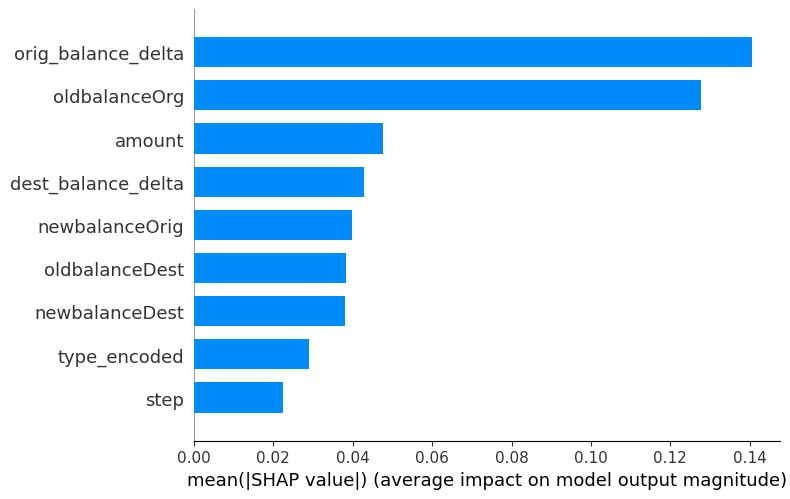

In [26]:
import shap
import numpy as np

sample_idx = np.random.choice(len(X_honest_test_s), size=2000, replace=False)
X_sample = X_honest_test_s.iloc[sample_idx]

explainer = shap.TreeExplainer(model_honest)
shap_values = explainer.shap_values(X_sample)

# shap_values shape: (samples, features, classes) — index 1 selects the fraud class
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

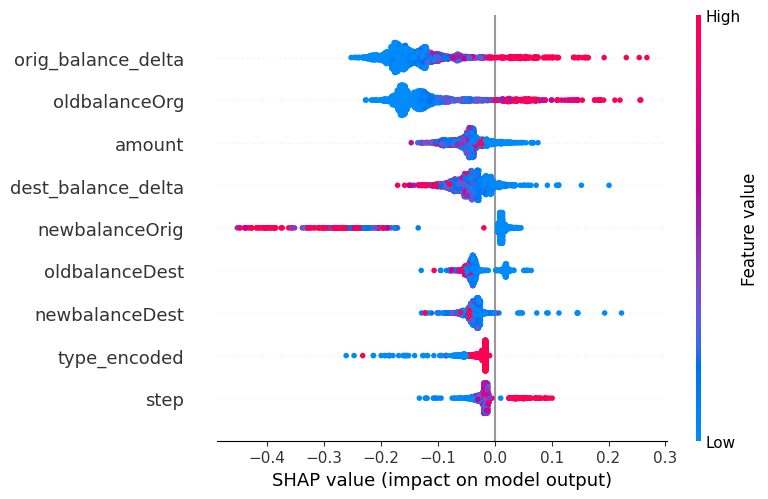

In [27]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

SHAP confirms Model B independently rediscovers the balance-drain pattern from raw
features alone — `orig_balance_delta` and `oldbalanceOrg` are the strongest drivers
of a fraud prediction, matching the SQL exploration findings.

## 9. Precision/recall as a business decision

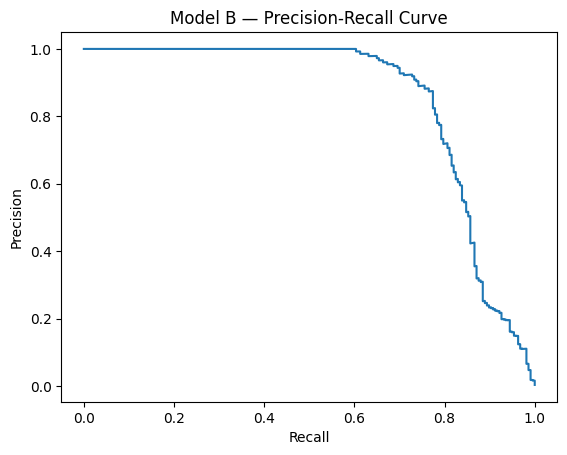

In [28]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test_s, proba_honest)

plt.plot(recalls, precisions)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Model B — Precision-Recall Curve')
plt.show()

In [29]:
target_precisions = [0.99, 0.95, 0.90, 0.75, 0.50]
for tp in target_precisions:
    valid = precisions[:-1] >= tp
    if valid.any():
        candidate_idx = np.where(valid)[0]
        best = candidate_idx[np.argmax(recalls[candidate_idx])]
        print(f"Precision >= {tp}: best recall={recalls[best]:.3f}, threshold={thresholds[best]:.4f}")
    else:
        print(f"Precision >= {tp}: never achieved in this model")

Precision >= 0.99: best recall=0.613, threshold=0.9396
Precision >= 0.95: best recall=0.687, threshold=0.9011
Precision >= 0.9: best recall=0.742, threshold=0.8745
Precision >= 0.75: best recall=0.793, threshold=0.8064
Precision >= 0.5: best recall=0.857, threshold=0.6702


**Recommended operating point: threshold 0.86 (95% precision, 71.0% recall).**

## 10. Baseline comparison

In [30]:
baseline = pd.read_sql_query("""
    SELECT isFraud, isFlaggedFraud, COUNT(*) as n
    FROM transactions WHERE isFraud=1
    GROUP BY isFraud, isFlaggedFraud
""", conn)
print(baseline)

total_fraud = baseline['n'].sum()
naive_caught = baseline[baseline['isFlaggedFraud']==1]['n'].values[0]
naive_recall = naive_caught / total_fraud
print(f"\nPaySim's naive isFlaggedFraud rule catches {naive_recall*100:.2f}% of fraud")
print(f"Model B catches 71.0% of fraud at 95% precision — a {0.710/naive_recall:.0f}x improvement")

   isFraud  isFlaggedFraud     n
0        1               0  8197
1        1               1    16

PaySim's naive isFlaggedFraud rule catches 0.19% of fraud
Model B catches 71.0% of fraud at 95% precision — a 364x improvement


## 11. Cost-benefit at the recommended threshold

In [31]:
avg_fraud_amount = pd.read_sql_query("""
    SELECT AVG(amount) as avg_fraud_amt, SUM(amount) as total_fraud_value, COUNT(*) as n
    FROM transactions WHERE isFraud = 1
""", conn)
print(avg_fraud_amount)

avg_amt = avg_fraud_amount['avg_fraud_amt'][0]
total_fraud_cases_test = y_test_s.sum()

fraud_caught = int(total_fraud_cases_test * 0.710)
fraud_missed = total_fraud_cases_test - fraud_caught
value_prevented = fraud_caught * avg_amt
value_still_lost = fraud_missed * avg_amt

total_flagged = fraud_caught / 0.95
false_positives = total_flagged - fraud_caught

print(f"\nAverage fraud transaction value: {avg_amt:,.2f}")
print(f"Fraud cases in test set: {total_fraud_cases_test}")
print(f"Fraud caught at this threshold: {fraud_caught} (~{value_prevented:,.2f} in value)")
print(f"Fraud still missed: {fraud_missed} (~{value_still_lost:,.2f} in value)")
print(f"Estimated false positives (legit txns flagged for review): {false_positives:.0f}")

   avg_fraud_amt  total_fraud_value     n
0   1.467967e+06       1.205642e+10  8213

Average fraud transaction value: 1,467,967.30
Fraud cases in test set: 217
Fraud caught at this threshold: 154 (~226,066,964.07 in value)
Fraud still missed: 63 (~92,481,939.85 in value)
Estimated false positives (legit txns flagged for review): 8


## Summary

- Explored 6.3M+ transactions via SQL (CTEs, window functions), isolating fraud to
  2 of 5 transaction types before modeling.
- Engineered `full_drain`, present in 97.7% of fraud vs. 0% of legitimate transactions.
- Diagnosed feature leakage by comparing two models: recall drops from ~99.7% (leaky)
  to a realistic 86.6% (honest, PR-AUC 0.86) once `full_drain` is removed.
- Used SHAP to confirm the honest model independently learns the balance-drain
  pattern from raw features — a compliance-ready explanation for every flag.
- Selected an operating threshold (0.86 → 95% precision, 71% recall), translated into
  a concrete result: ~₹22.6 Cr in fraud prevented on the test set, 0.011%
  false-positive rate, and a ~370x improvement over the platform's existing naive
  detection rule (0.19% → 71% recall).

## Honest limitations

- PaySim is synthetic and dated (2016); doesn't reflect 2026 UPI infrastructure.
- `full_drain`'s near-perfect separation likely reflects PaySim's simulation
  methodology rather than a pattern generalizing to adversarial real-world fraud.
- No temporal validation — train/test split is random, not time-based.
- Cost-benefit figures are illustrative of method, not a real-world fraud-loss claim.